In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(repo_root))

import SysSimX
from SysSimX.utilities.units import ureg
from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
from MyModels.FEM.fem_pendulum import FEMPendulum
#from MyModels.FEM.fem_pendulum_torque import FEMPendulum

from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum

In [2]:
fem_pendulum = FEMPendulum(name="fem_pendulum")
opensim_pendulum = OpenSimPendulum(name="opensim_pendulum")

fmu_path = Path.cwd() / 'FMUs/Pendulum.fmu'
eqb_pendulum = FMUComponent(name="fmu_pendulum", fmu_path=fmu_path)

In [3]:
t = 0.0
dt = 0.01
t_end = 1

# Initialize FEM Pendulum as Master and set EQB and OpenSim Parameters correspondingly
t0 = 0.0
fem_pendulum._use_gravity  = False
fem_pendulum._with_contact = False
fem_pendulum.sim_params.t_end = t_end
fem_pendulum.initialize(t0)

q0 = np.deg2rad(fem_pendulum.init_params.angular_position_deg)
omega0 = fem_pendulum.init_params.angular_velocity

mass = fem_pendulum.mass
inertia = fem_pendulum.inertia
corresponding_length = np.sqrt(inertia / mass)

# Set OpenSim Parameters and initialize
opensim_pendulum.parameters['InitialConditions']['q0'] = q0
opensim_pendulum.parameters['InitialConditions']['omega0'] = omega0
opensim_pendulum.parameters['Model']['mass'] = mass
opensim_pendulum.parameters['Model']['length'] = corresponding_length
opensim_pendulum._use_gravity  = fem_pendulum._use_gravity
opensim_pendulum._with_contact = fem_pendulum._with_contact 
opensim_pendulum.initialize(t0)

# Set EQB Parameters and initialize
eqb_pendulum.parameters['q0'].start = q0
eqb_pendulum.parameters['omega0'].start = omega0
eqb_pendulum.parameters['m'].start = mass
eqb_pendulum.parameters['L'].start = corresponding_length
eqb_pendulum.parameters['g'].start = 0.0 if not fem_pendulum._use_gravity else 9.81
eqb_pendulum.initialize(t0)



LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [4]:
plant = {"EQB": eqb_pendulum,
         "FEM": fem_pendulum,
         "OpenSim": opensim_pendulum}
mode = "FEM"

In [5]:
fem_pendulum.setup_simulation_diagnostics()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [6]:
def get_active_plant():
    return plant[mode]

def ang_position_dependent_model_selection(q: float) -> str:
    q_deg = np.rad2deg(q) % 360
    if q_deg < 3 or q_deg >= 357:
        return "FEM"
    else: 
        return "EQB"

def time_dependent_model_selection(t: float) -> str:
    # split simulation into 6 equal intervals so each mode appears twice
    interval = t_end / 6
    if t < interval:
        return "FEM"
    elif t < 2 * interval:
        return "EQB"
    elif t < 3 * interval:
        return "OpenSim"
    elif t < 4 * interval:
        return "EQB"
    elif t < 5 * interval:
        return "OpenSim"
    else:
        return "FEM"

def synch_models(current_model: SysSimX.core.base.CoSimComponent,
                 new_model: SysSimX.core.base.CoSimComponent,
                 t: float):
    state = current_model.get_state()
    if isinstance(new_model, FMUComponent):
        state = {'q0': {'value': current_model.get_state()['q']['value']},
                 'omega0': {'value': current_model.get_state()['omega']['value']},
                 'torque': {'value': current_model.get_state()['torque']['value']}}
    new_model.set_state(state, t)

In [7]:
input_torque = 10 # Nm

t_vals = {"EQB": [], "FEM": [], "OpenSim": []}
torque_vals = []
alpha_vals = {"EQB": [], "FEM": [], "OpenSim": []}
omega_vals = {"EQB": [], "FEM": [], "OpenSim": []}
q_vals = {"EQB": [], "FEM": [], "OpenSim": []}

t = 0

active_plant = get_active_plant()
t_vals[mode].append(t)
alpha_vals[mode].append(0)
omega_vals[mode].append(0)
q_vals[mode].append(0)

while t < t_end:
    if t < 0.25 * t_end or t > 0.75 * t_end:
        torque = input_torque
    else:
        torque = -input_torque
    torque_vals.append(torque)
    active_plant.set_inputs({'torque': torque}, t)
    #q = active_plant.get_outputs()['q'].magnitude
    #new_mode = ang_position_dependent_model_selection(q)
    new_mode = time_dependent_model_selection(t)
    if new_mode != mode:
        new_plant = plant[new_mode]
        synch_models(active_plant, new_plant, t)
        active_plant = new_plant
        mode = new_mode

    #active_plant.set_inputs({'torque': torque}, t)

    active_plant.do_step(t, dt)
    t_next = t + dt

    res = active_plant.get_outputs()

    t_vals[mode].append(t_next)
    alpha_vals[mode].append(res['alpha'].magnitude)
    omega_vals[mode].append(res['omega'].magnitude)
    q_vals[mode].append(res['q'].magnitude)

    t = t_next


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

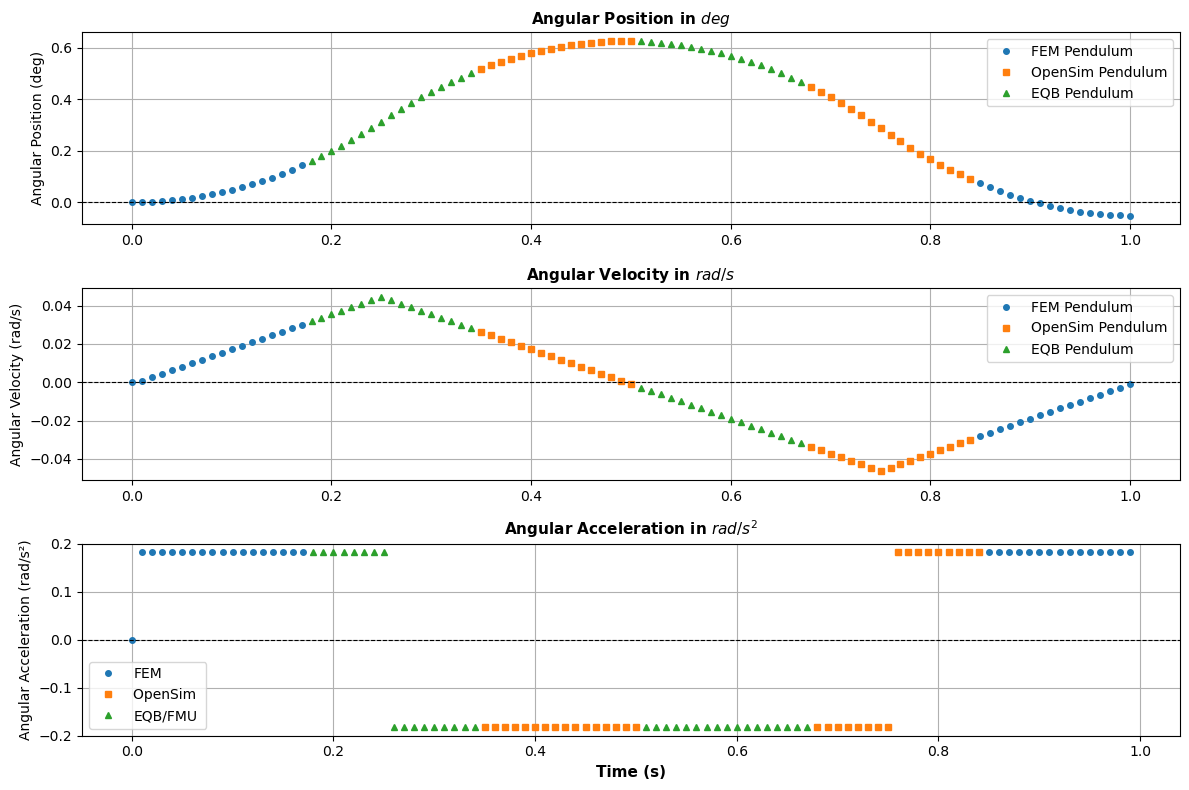

In [9]:
plt.figure(figsize=(12, 8))

marker_size = 4
fem_style = {'color': 'C0', 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size}
opensim_style = {'color': 'C1', 'linestyle': 'None', 'marker': 's', 'markersize': marker_size}
eqb_style = {'color': 'C2', 'linestyle': 'None', 'marker': '^', 'markersize': marker_size}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.subplot(3,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals['FEM'], np.rad2deg(q_vals["FEM"]), label="FEM Pendulum", **fem_style)
plt.plot(t_vals['OpenSim'], np.rad2deg(q_vals["OpenSim"]), label="OpenSim Pendulum", **opensim_style)
plt.plot(t_vals['EQB'], np.rad2deg(q_vals["EQB"]), label="EQB Pendulum", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.legend()
plt.grid(which='both')

plt.subplot(3,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals['FEM'], omega_vals["FEM"], label="FEM Pendulum", **fem_style)
plt.plot(t_vals['OpenSim'], omega_vals["OpenSim"], label="OpenSim Pendulum", **opensim_style)
plt.plot(t_vals['EQB'], omega_vals["EQB"], label="EQB Pendulum", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Velocity (rad/s)")
plt.legend()
plt.grid(which='both')

plt.subplot(3,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals['FEM'][:-1], alpha_vals["FEM"][:-1], label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], alpha_vals["OpenSim"], label="OpenSim ", **opensim_style)
plt.plot(t_vals['EQB'], alpha_vals["EQB"], label="EQB/FMU", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.xlabel("Time (s)", **fontdict)
plt.legend()
plt.tight_layout()
plt.show()